<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/Learning%20and%20Optimization/Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
class SGD:
  def __init__(self, lr=0.01):
    self.lr = lr

  def update(self, params, grads):
    for key in params.keys():
      params[key]-=self.lr*grads[key]

In [ ]:
class Momentum:
  def __init__(self,lr=0.01, momentum=0.9):
    self.lr=lr
    self.momentum=momentum
    self.v=None

  def update(self, params, grads):
    if self.v is None:
      self.v={}
      for key,val in params.items():
        self.v[key]=np.zeros_like(val)

    for key in params.keys():
      self.v[key]=self.momentum*self.v[key]+self.lr*grads[key]
      params[key]-=self.v[key]

In [ ]:
class NAG:
  def __init__(self,lr=0.01, momentum=0.9):
    self.lr=lr
    self.momentum=momentum
    self.v=None


  def prev(self,params):
    if self.v is None:
      self.v={}

      for key,val in params.items():
        self.v[key]=np.zeros_like(val)

    tmp={}

    for key in params.keys():
      tmp[key]=params[key]-self.momentum*self.v[key]

    return tmp

  def update(self, params, grads):

    for key in params.keys():
      self.v[key]=self.momentum*self.v[key]+self.lr*grads[key]
      params[key]-=self.v[key]

pytorch에서 NAG를 사용할때는 nesterov=True 옵션으로 구현
backward할때 순서대로 코드를 보지 않고 해석을 하는 interpreter로 읽기에 관성법칙까지 적용된 파라미터에서 역전파

In [ ]:
class Adagrad:
  def __init__(self, lr=0.01):
    self.lr = lr
    self.h=None

  def update(self, params, grads):
    if self.h is None:
      self.h={}
      for key,val in params.items():
        self.h[key]=np.zeros_like(val)

    for key in params.keys():
      self.h[key]+=grads[key]*grads[key]
      params[key]-=self.lr*grads[key]/(np.sqrt(self.h[key])+1e-7)

In [ ]:
class RMSprop:
  def __init__(self, lr=0.01, momentum=0.9):
    self.lr=lr
    self.momentum=momentum
    self.e=None

  def update(self,params,grads):
    if self.e is None:
      self.e={}
      for key,val in params.items():
        self.e[key]=np.zeros_like(val)

    for key in params.keys():
      self.e[key]=self.momentum*self.e[key]+(1-self.momentum)*grads[key]*grads[key]
      params[key]-=self.lr*grads[key]/(np.sqrt(self.e[key])+1e-7)

In [ ]:
class Adadelta:
  def __init__(self, momentum=0.9):
    self.momentum=momentum
    self.msdx=None
    self.msg=None

  def update(self,params,grads):
    if self.msg is None:
      self.msdx={}
      self.msg={}
      for key,val in params.items():
        self.msdx[key]=np.zeros_like(val)
        self.msg[key]=np.zeros_like(val)


    for key in params.keys():
      self.msg[key]=self.momentum*self.msg[key]+(1-self.momentum)*grads[key]*grads[key]
      rms_dx = np.sqrt(self.msdx[key]+1e-7)
      rms_g = np.sqrt(self.msg[key]+1e-7)
      dx=-(rms_dx / rms_g) * grads[key]
      self.msdx[key]=self.momentum*self.msdx[key]+(1-self.momentum)*dx*dx
      params[key]+=dx

In [ ]:
class Adam:
  def __init__(self,lr=0.001,beta1=0.9,beta2=0.999):
    self.lr=lr
    self.beta1=beta1
    self.beta2=beta2
    self.t=0
    self.m=None
    self.v=None

  def update(self,params,grads):
    if self.m is None:
      self.m={}
      self.v={}
      for key,val in params.items():
        self.m[key]=np.zeros_like(val)
        self.v[key]=np.zeros_like(val)

    self.t+=1
    for key in params.keys():
      grad=grads[key]
      self.m[key]=self.beta1*self.m[key]+(1-self.beta1)*grad
      self.v[key]=self.beta2*self.v[key]+(1-self.beta2)*grad**2
      m_hat=self.m[key]/(1-self.beta1**self.t)
      v_hat=self.v[key]/(1-self.beta2**self.t)
      params[key]-=self.lr*m_hat/(np.sqrt(v_hat)+1e-8)

In [ ]:
class Adamax:
  def __init__(self,lr=0.002,beta1=0.9,beta2=0.999):
    self.lr=lr
    self.beta1=beta1
    self.beta2=beta2
    self.t=0
    self.m=None
    self.u=None

  def update(self,params,grads):
    if self.m is None:
      self.m={}
      self.u={}
      for key,val in params.items():
        self.m[key]=np.zeros_like(val)
        self.u[key]=np.zeros_like(val)

    self.t+=1
    for key in params.keys():
      grad=grads[key]
      self.m[key]=self.beta1*self.m[key]+(1-self.beta1)*grad
      self.u[key]=np.maximum(self.beta2*self.u[key],abs(grad))
      params[key]-=(self.lr/(1-self.beta1**self.t))*self.m[key]/(self.u[key]+1e-8)

In [ ]:
class Nadam:
  def __init__(self,lr=0.001,beta1=0.9,beta2=0.999):
    self.lr=lr
    self.beta1=beta1
    self.beta2=beta2
    self.t=0
    self.m=None
    self.v=None

  def update(self,params,grads):
    if self.m is None:
      self.m={}
      self.v={}
      for key,val in params.items():
        self.m[key]=np.zeros_like(val)
        self.v[key]=np.zeros_like(val)

    self.t+=1
    for key in params.keys():
      grad=grads[key]
      self.m[key]=self.beta1*self.m[key]+(1-self.beta1)*grad
      self.v[key]=self.beta2*self.v[key]+(1-self.beta2)*grad**2
      m_hat=self.m[key]/(1-self.beta1**self.t)
      v_hat=self.v[key]/(1-self.beta2**self.t)
      g_hat=grad/(1-self.beta1**self.t)
      params[key]-=self.lr*(self.beta1*m_hat+(1-self.beta1)*g_hat)/(np.sqrt(v_hat)+1e-8)

In [ ]:
optimizers={}
optimizers['SGD']=SGD(lr=0.95)
optimizers['Momentum']=Momentum(lr=0.1)
optimizers['NAG']=NAG(lr=0.1)
optimizers['Adagrad']=Adagrad(lr=1.5)
optimizers['Adadelta']=Adadelta()
optimizers['RMSprop']=RMSprop(lr=0.3)
optimizers['Adam']=Adam(lr=0.3)
optimizers['Adamax']=Adamax(lr=0.3)
optimizers['Nadam']=Nadam(lr=0.3)

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

In [ ]:
init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0

In [ ]:
x = np.arange(-10, 10, 0.01)
y = np.arange(-5, 5, 0.01)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

SGD fin


/tmp/ipykernel_10012/2738395495.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go" (-> color='g'). The keyword argument will take precedence.
  ax.plot(x_history[0], y_history[0], 'go',color='blue')  # start
/tmp/ipykernel_10012/2738395495.py:38: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x_history[-1], y_history[-1], 'ro',color='blue')  # end


Momentum fin
NAG fin
Adagrad fin
Adadelta fin
RMSprop fin
Adam fin
Adamax fin
Nadam fin


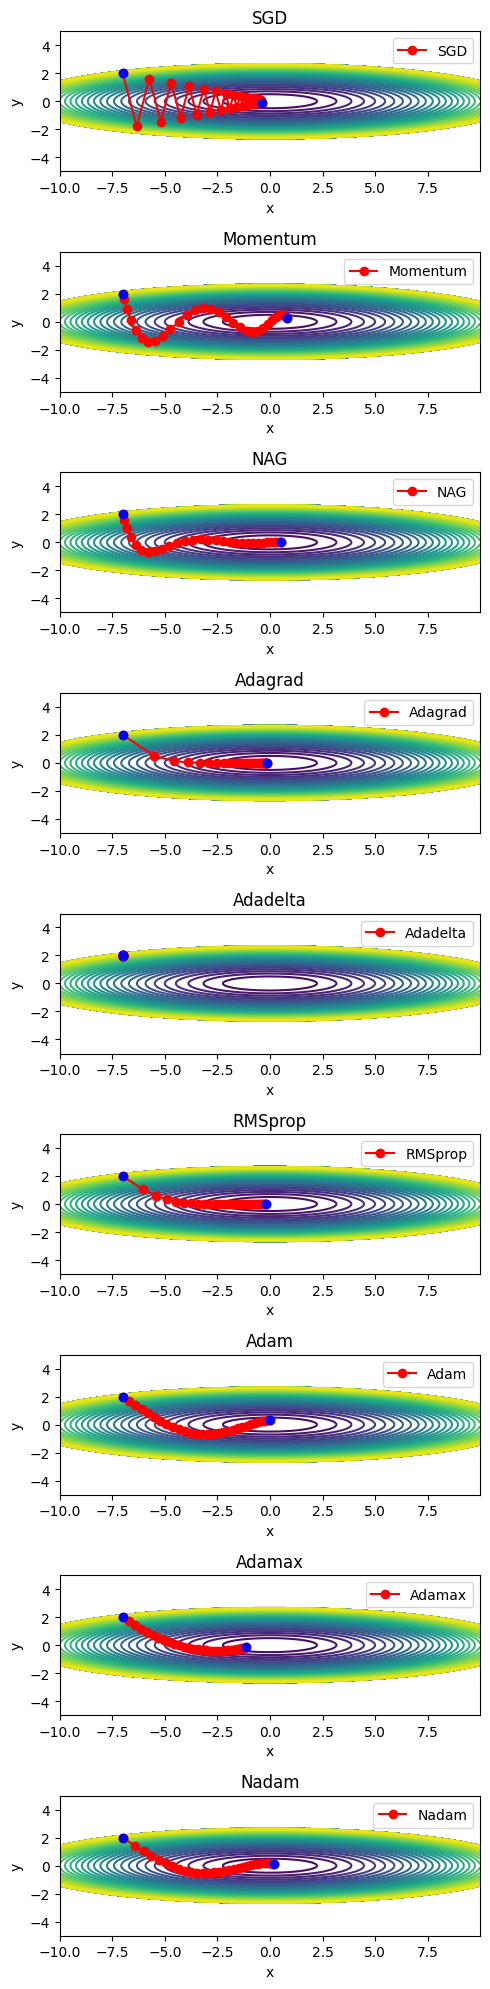

In [ ]:
fig, axes = plt.subplots(len(optimizers), 1, figsize=(5, 20))

if len(optimizers) == 1:
    axes = [axes]


for ax, (name, optimizer) in zip(axes, optimizers.items()):

    params = {'x': init_pos[0], 'y': init_pos[1]}
    grads = {'x': 0, 'y': 0}

    x_history = []
    y_history = []

    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])

        if isinstance(optimizer, NAG):
          prev_params = optimizer.prev(params)
          grads['x'], grads['y'] = df(prev_params['x'], prev_params['y'])
        else:
          grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)

    print(name + " fin")

    mask = Z > 7
    Z[mask] = 0
    # ===== contour =====
    ax.contour(X, Y, Z, levels=30)

    # ===== 경로 =====
    ax.plot(x_history, y_history, 'o-', label=name,color='red')

    # 시작점 / 끝점 강조
    ax.plot(x_history[0], y_history[0], 'go',color='blue')  # start
    ax.plot(x_history[-1], y_history[-1], 'ro',color='blue')  # end

    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.tight_layout()
plt.show()




Adadelta만 제대로 안 되는 이유는 학습률을 컨트롤 할 수가 없음. 실무에서 잘 안 쓰이는 이유가 이거인듯. (iteration 5000정도 박으면 제대로 나옴)

ADAM <- 쟤가 좀 레전드임.